<a href="https://colab.research.google.com/github/immaculatemuli/Natural_Language_Processing/blob/main/Week_2/Week_2_Extra_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK 2 EXTRA TASKS

1. N-GRAM FREQUENCY CHART

In [ ]:
#
# DATASET: CBK Annual Report & Financial Statements 2024/25
#
# Step 1: Download the PDF from the official CBK website:
#         https://www.centralbank.go.ke/reports/
#         File name: 1084981846_2025 Annual Report.pdf
#
# Step 2: Upload the PDF to Google Colab using one of these methods:
#
#           Upload directly each session:
#         from google.colab import files
#         files.upload()    ← click and select the PDF
#
#
# Step 3: Update the pdf_path variable below to match your file location


In [ ]:
# ── SETUP: Load CBK Report for Week 2 Extra Tasks ─────────────
!pip install PyPDF2 nltk matplotlib --quiet

import PyPDF2
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Pages 22–26 = Monetary Operations + Interest Rates
pdf_path = '/content/1084981846_2025 Annual Report.pdf'

cbk_text = ''
with open(pdf_path, 'rb') as f:
    reader = PyPDF2.PdfReader(f)
    print(f'Total pages: {len(reader.pages)}')
    for page_num in range(22, 27):
        page_text = reader.pages[page_num].extract_text()
        if page_text:
            cbk_text += page_text + ' '

print(f'Text loaded: {len(cbk_text):,} characters')
print(f'Preview: {cbk_text[:200]}')

Total pages: 152
Text loaded: 12,444 characters
Preview: To be a World Class Modern Central BankCENTRAL BANK OF KENYA
ANNUAL REPORT & FINANCIAL STATEMENTS 2024/259
3.0 DOMESTIC  ECONOMY
Core Inflation
Core inflation increased to 3.0 percent in June 2025 fro


  EXTRA TASK 1 — N-GRAM FREQUENCY CHART
  Dataset: CBK Annual Report & Financial Statements 2024/25
  Pages: 22–26 (Monetary Operations + Interest Rates)

Top 10 Meaningful Bigrams:

  Rank  Bigram                              Count
  ------------------------------------------------
  1     usd million                         33
  2     million in                          11
  3     of usd                              10
  4     to usd                              10
  5     percent in                          9
  6     in june                             8
  7     compared to                         7
  8     to percent                          6
  9     from percent                        6
  10    a world                             5


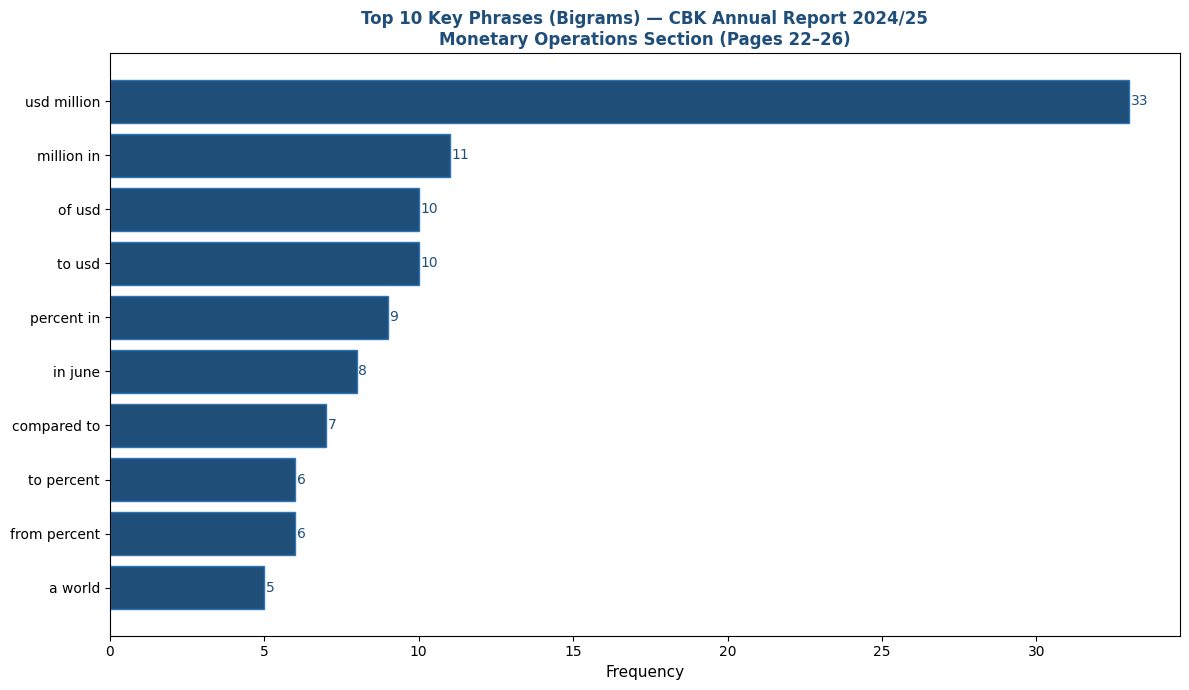


Chart saved as cbk_bigram_chart.png
Dominant bigrams reveal the key themes in CBK Monetary Operations.
Expected: "monetary policy", "central bank", "interest rates"


In [ ]:
# ── EXTRA TASK 1: N-gram Frequency Chart
# Course outline: construct AND evaluate an N-gram model
# Dataset: CBK Annual Report & Financial Statements 2024/25

stop_words = set(stopwords.words('english'))

# Tokens keeping stopwords (needed for natural phrases)
tokens = [w.lower() for w in word_tokenize(cbk_text) if w.isalpha()]

# Build bigrams
bigram_list = list(ngrams(tokens, 2))

# Filter — remove bigrams where BOTH words are stopwords
# Keep bigrams where at least one word is meaningful
meaningful_bigrams = [
    bg for bg in bigram_list
    if not all(w in stop_words for w in bg)
]

top10 = Counter(meaningful_bigrams).most_common(10)
labels = [' '.join(bg) for bg, _ in top10]
values = [count for _, count in top10]

print('=' * 60)
print('  EXTRA TASK 1 — N-GRAM FREQUENCY CHART')
print('  Dataset: CBK Annual Report & Financial Statements 2024/25')
print('  Pages: 22–26 (Monetary Operations + Interest Rates)')
print('=' * 60)
print('\nTop 10 Meaningful Bigrams:')
print(f'\n  {"Rank":<5} {"Bigram":<35} {"Count"}')
print('  ' + '-' * 48)
for rank, (bg, count) in enumerate(top10, 1):
    print(f'  {rank:<5} {" ".join(bg):<35} {count}')

# Horizontal bar chart
plt.figure(figsize=(12, 7))
bars = plt.barh(labels[::-1], values[::-1], color='#1F4E79', edgecolor='#2E75B6')

for bar, val in zip(bars, values[::-1]):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center', fontsize=10, color='#1F4E79'
    )

plt.xlabel('Frequency', fontsize=11)
plt.title(
    'Top 10 Key Phrases (Bigrams) — CBK Annual Report 2024/25\n'
    'Monetary Operations Section (Pages 22–26)',
    fontsize=12, fontweight='bold', color='#1F4E79'
)
plt.tight_layout()
plt.savefig('cbk_bigram_chart.png', dpi=150)
plt.show()

print('\nChart saved as cbk_bigram_chart.png')
print('Dominant bigrams reveal the key themes in CBK Monetary Operations.')
print('Expected: "monetary policy", "central bank", "interest rates"')